In [83]:
!pip install -U imbalanced-learn

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re

In [85]:
import warnings
warnings.filterwarnings('ignore')

In [86]:
gossipcop_fake_df = pd.read_csv('gossipcop_fake.csv')
gossipcop_real_df = pd.read_csv('gossipcop_real.csv')

politifact_fake_df = pd.read_csv('politifact_fake.csv')
politifact_real_df = pd.read_csv('politifact_real.csv')

In [87]:
fake_df = pd.concat([gossipcop_fake_df, politifact_fake_df])
true_df = pd.concat([gossipcop_real_df, politifact_real_df])

fake_df.index = [x for x in range(len(gossipcop_fake_df) + len(politifact_fake_df))]
true_df.index = [x for x in range(len(gossipcop_real_df) + len(politifact_real_df))]


In [88]:
# add labels to both df
true_df['true'] = 1
fake_df['true'] = 0


In [89]:
df = pd.concat([true_df, fake_df])
len(df)

23196

In [90]:
display(df)

,id,news_url,title,tweet_ids,true
0,gossipcop-882573,https://www.brides.com/story/teen-mom-jenelle-...,Teen Mom Star Jenelle Evans' Wedding Dress Is ...,912371411146149888\t912371528343408641\t912372...,1
1,gossipcop-875924,https://www.dailymail.co.uk/tvshowbiz/article-...,Kylie Jenner refusing to discuss Tyga on Life ...,901989917546426369\t901989992074969089\t901990...,1
2,gossipcop-894416,https://en.wikipedia.org/wiki/Quinn_Perkins,Quinn Perkins,931263637246881792\t931265332022579201\t931265...,1
3,gossipcop-857248,https://www.refinery29.com/en-us/2018/03/19192...,I Tried Kim Kardashian's Butt Workout & Am For...,868114761723936769\t868122567910936576\t868128...,1
4,gossipcop-884684,https://www.cnn.com/2017/10/04/entertainment/c...,Celine Dion donates concert proceeds to Vegas ...,915528047004209152\t915529285171122176\t915530...,1
...,...,...,...,...,...
5750,politifact14944,http://thehill.com/homenews/senate/369928-who-...,Who is affected by the government shutdown?,954602090462146560\t954602093171609600\t954650...,0
5751,politifact14071,https://web.archive.org/web/20170322070001/htt...,Lindsey Graham Threatens To Convert To Democra...,740351669834244096\t740391312277573632\t740474...,0
5752,politifact13577,http://archive.is/DQqCx,ELECTORAL COLLEGE ELECTOR COMMITS SUICIDE TO A...,810939651900907520\t814738996706164737\t814917...,0
5753,politifact13560,politicono.com/palin-calls-boycott-mall-americ...,Sarah Palin Calls To Boycott Mall Of America B...,805216591424212993\t805222830023540736\t805223...,0


In [91]:
true_counts = df['true'].value_counts()

print("Number of Total True News:", true_counts[1])
print("Number of Total Fake news:", true_counts[0])

Number of Total True News: 17441
Number of Total Fake news: 5755


In [92]:
df.drop_duplicates()
df.dropna()

,id,news_url,title,tweet_ids,true
0,gossipcop-882573,https://www.brides.com/story/teen-mom-jenelle-...,Teen Mom Star Jenelle Evans' Wedding Dress Is ...,912371411146149888\t912371528343408641\t912372...,1
1,gossipcop-875924,https://www.dailymail.co.uk/tvshowbiz/article-...,Kylie Jenner refusing to discuss Tyga on Life ...,901989917546426369\t901989992074969089\t901990...,1
2,gossipcop-894416,https://en.wikipedia.org/wiki/Quinn_Perkins,Quinn Perkins,931263637246881792\t931265332022579201\t931265...,1
3,gossipcop-857248,https://www.refinery29.com/en-us/2018/03/19192...,I Tried Kim Kardashian's Butt Workout & Am For...,868114761723936769\t868122567910936576\t868128...,1
4,gossipcop-884684,https://www.cnn.com/2017/10/04/entertainment/c...,Celine Dion donates concert proceeds to Vegas ...,915528047004209152\t915529285171122176\t915530...,1
...,...,...,...,...,...
5750,politifact14944,http://thehill.com/homenews/senate/369928-who-...,Who is affected by the government shutdown?,954602090462146560\t954602093171609600\t954650...,0
5751,politifact14071,https://web.archive.org/web/20170322070001/htt...,Lindsey Graham Threatens To Convert To Democra...,740351669834244096\t740391312277573632\t740474...,0
5752,politifact13577,http://archive.is/DQqCx,ELECTORAL COLLEGE ELECTOR COMMITS SUICIDE TO A...,810939651900907520\t814738996706164737\t814917...,0
5753,politifact13560,politicono.com/palin-calls-boycott-mall-americ...,Sarah Palin Calls To Boycott Mall Of America B...,805216591424212993\t805222830023540736\t805223...,0


In [93]:
X = df.drop(['true'], axis=1)
y = df['true']

In [94]:
y.value_counts()

1    17441
0     5755
Name: true, dtype: int64

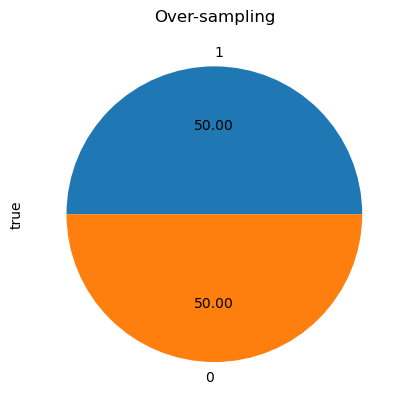

In [95]:
from imblearn.over_sampling import RandomOverSampler

ROS = RandomOverSampler(sampling_strategy=1)
X_ros, y_ros = ROS.fit_resample(X,y)

ax = y_ros.value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title('Over-sampling')

In [98]:
df.drop(columns = ["id", "news_url", "tweet_ids"])

,title,true
0,Teen Mom Star Jenelle Evans' Wedding Dress Is ...,1
1,Kylie Jenner refusing to discuss Tyga on Life ...,1
2,Quinn Perkins,1
3,I Tried Kim Kardashian's Butt Workout & Am For...,1
4,Celine Dion donates concert proceeds to Vegas ...,1
...,...,...
5750,Who is affected by the government shutdown?,0
5751,Lindsey Graham Threatens To Convert To Democra...,0
5752,ELECTORAL COLLEGE ELECTOR COMMITS SUICIDE TO A...,0
5753,Sarah Palin Calls To Boycott Mall Of America B...,0


In [99]:
from sklearn.utils import shuffle

df = df.iloc[:,[2, -1]]  
df = shuffle(df).reset_index(drop=True)  
display(df)

,title,true
0,Arie Luyendyk Jr. and Fiancee Lauren Burnham H...,1
1,Who won 'American Idol' 2018? Winner revealed ...,1
2,Prince Philip is retiring from royal duties,1
3,'Fixer Upper's' Chip Gaines shaves head for St...,1
4,Megyn Kelly Claps Back at Jane Fonda Over Plas...,1
...,...,...
23191,"DJ Khaled, Chance, Justin Bieber, Quavo Share ...",1
23192,Justin Bieber is taking a break from music to ...,1
23193,How Jennifer Aniston Is Coping After Split: Sh...,0
23194,Man arrested in Young Dolph shooting; Yo Gotti...,1


In [100]:
df['title'] = (df['title'].str.lower())
print(df)

                                                   title  true
0      arie luyendyk jr. and fiancee lauren burnham h...     1
1      who won 'american idol' 2018? winner revealed ...     1
2            prince philip is retiring from royal duties     1
3      'fixer upper's' chip gaines shaves head for st...     1
4      megyn kelly claps back at jane fonda over plas...     1
...                                                  ...   ...
23191  dj khaled, chance, justin bieber, quavo share ...     1
23192  justin bieber is taking a break from music to ...     1
23193  how jennifer aniston is coping after split: sh...     0
23194  man arrested in young dolph shooting; yo gotti...     1
23195                                         anmer hall     0

[23196 rows x 2 columns]


In [101]:
df['title'] = df['title'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
df.head()

,title,true
0,arie luyendyk jr. and fiancee lauren burnham h...,1
1,who won 'american idol' 2018? winner revealed ...,1
2,prince philip is retiring from royal duties,1
3,'fixer upper's' chip gaines shaves head for st...,1
4,megyn kelly claps back at jane fonda over plas...,1


In [102]:
df['title'] = df['title'].str.replace(r"[\"\'\|\?\=\.\<\>\@\#\*\,]", '')
df.head()

,title,true
0,arie luyendyk jr and fiancee lauren burnham ha...,1
1,who won american idol 2018 winner revealed in ...,1
2,prince philip is retiring from royal duties,1
3,fixer uppers chip gaines shaves head for st ju...,1
4,megyn kelly claps back at jane fonda over plas...,1


In [103]:
def tokenize(txt):
    tokens = re.split('\W+', txt)
    return tokens

In [104]:
df['title'] = df['title'].apply(lambda x: tokenize(x.lower()))
df.head()

,title,true
0,"[arie, luyendyk, jr, and, fiancee, lauren, bur...",1
1,"[who, won, american, idol, 2018, winner, revea...",1
2,"[prince, philip, is, retiring, from, royal, du...",1
3,"[fixer, uppers, chip, gaines, shaves, head, fo...",1
4,"[megyn, kelly, claps, back, at, jane, fonda, o...",1


In [105]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [106]:
def remove_punctuation(txt):
    txt_nopunct = " ".join([c for c in txt if c not in string.punctuation])
    return txt_nopunct

In [107]:
df['title'] = df['title'].apply(lambda x : remove_punctuation(x))
df.head()

,title,true
0,arie luyendyk jr and fiancee lauren burnham ha...,1
1,who won american idol 2018 winner revealed in ...,1
2,prince philip is retiring from royal duties,1
3,fixer uppers chip gaines shaves head for st ju...,1
4,megyn kelly claps back at jane fonda over plas...,1


In [108]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [109]:
from nltk.corpus import stopwords

In [110]:
",".join(stopwords.words('english'))

"i,me,my,myself,we,our,ours,ourselves,you,you're,you've,you'll,you'd,your,yours,yourself,yourselves,he,him,his,himself,she,she's,her,hers,herself,it,it's,its,itself,they,them,their,theirs,themselves,what,which,who,whom,this,that,that'll,these,those,am,is,are,was,were,be,been,being,have,has,had,having,do,does,did,doing,a,an,the,and,but,if,or,because,as,until,while,of,at,by,for,with,about,against,between,into,through,during,before,after,above,below,to,from,up,down,in,out,on,off,over,under,again,further,then,once,here,there,when,where,why,how,all,any,both,each,few,more,most,other,some,such,no,nor,not,only,own,same,so,than,too,very,s,t,can,will,just,don,don't,should,should've,now,d,ll,m,o,re,ve,y,ain,aren,aren't,couldn,couldn't,didn,didn't,doesn,doesn't,hadn,hadn't,hasn,hasn't,haven,haven't,isn,isn't,ma,mightn,mightn't,mustn,mustn't,needn,needn't,shan,shan't,shouldn,shouldn't,wasn,wasn't,weren,weren't,won,won't,wouldn,wouldn't"

In [111]:
stop_words = set(stopwords.words('english'))

In [112]:
def remove_stop(x):
    return ",".join([word for word in str(x).split() if word not in stop_words])

In [113]:
df['title'] = df['title'].apply(lambda x : remove_stop(x))
df.head()

,title,true
0,"arie,luyendyk,jr,fiancee,lauren,burnham,offici...",1
1,"american,idol,2018,winner,revealed,season,finale",1
2,"prince,philip,retiring,royal,duties",1
3,"fixer,uppers,chip,gaines,shaves,head,st,jude,c...",1
4,"megyn,kelly,claps,back,jane,fonda,plastic,surg...",1


In [114]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [115]:
lemmatizer = WordNetLemmatizer()

In [116]:
def data_processing(data):
    data = [lemmatizer.lemmatize(word) for word in data]
    data = ''.join(data)
    return data

In [117]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [118]:
df['title'] = df['title'].apply(lambda data: data_processing(data))
df.head()

,title,true
0,"arie,luyendyk,jr,fiancee,lauren,burnham,offici...",1
1,"american,idol,2018,winner,revealed,season,finale",1
2,"prince,philip,retiring,royal,duties",1
3,"fixer,uppers,chip,gaines,shaves,head,st,jude,c...",1
4,"megyn,kelly,claps,back,jane,fonda,plastic,surg...",1


In [119]:
train_df = df.sample(frac=0.8)
test_df = df.drop(train_df.index)

# reset index
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('trainset size:', train_df.shape)
print('testset size:', test_df.shape)

trainset size: (18557, 2)
testset size: (4639, 2)


In [120]:
print('ISOT length:', len(test_df))

print('Train real news:', train_df[train_df['true']==1].shape[0])
print('Train fake news:', train_df[train_df['true']==0].shape[0])

print('Test real news:', test_df[test_df['true']==1].shape[0])
print('Test fake news:', test_df[test_df['true']==0].shape[0])

ISOT length: 4639
Train real news: 13924
Train fake news: 4633
Test real news: 3517
Test fake news: 1122


In [121]:
X_train = train_df['title']
X_test = test_df['title']

y_train = train_df['true']
y_test = test_df['true']

print('Train data:', X_train.shape, y_train.shape)
print('Test data:', X_test.shape, y_test.shape)

Train data: (18557,) (18557,)
Test data: (4639,) (4639,)


In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=10)

X_train_news_tfidf = vectorizer.fit_transform(X_train)
X_test_news_tfidf = vectorizer.transform(X_test)

print('X_train_news_tfidf shape:', X_train_news_tfidf.shape)
print('X_test_news_tfidf shape:', X_test_news_tfidf.shape)

X_train_news_tfidf shape: (18557, 2809)
X_test_news_tfidf shape: (4639, 2809)


In [123]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = MultinomialNB()

param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf,y_train)

best_params = grid_search.best_params_

final_clf = MultinomialNB(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('NB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

NB Classifier
Best hyperparameters: {'alpha': 0.5}
Accuracy:  0.8370338435007545
Precision:  0.8522582291400868
Recall:  0.9496730167756611
F1-score:  0.8983324367939752


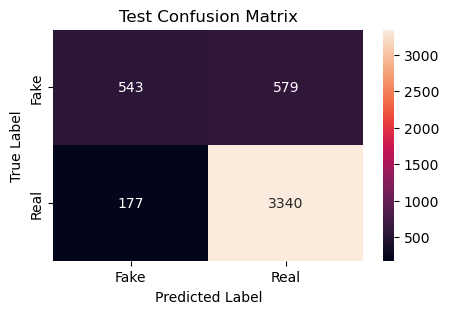

In [124]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = RandomForestClassifier()

param_grid = {'max_depth':[None,10,20], 'min_samples_leaf':[1,2,4], 'min_samples_split':[2,5,10], 'n_estimators':[10,50,100]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = RandomForestClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('RF Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

RF Classifier
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy:  0.8327225695192929
Precision:  0.8549598549598549
Recall:  0.9385840204719932
F1-score:  0.8948224451070751


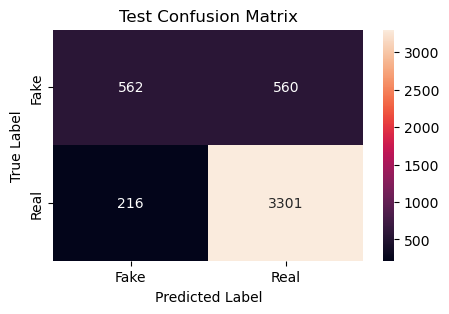

In [126]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = LogisticRegression()

param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100], 'penalty':['l1', 'l2']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = LogisticRegression(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('LR Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

LR Classifier
Best hyperparameters: {'C': 1, 'penalty': 'l2'}
Accuracy:  0.8400517352877775
Precision:  0.8506444275966641
Recall:  0.9570656809781063
F1-score:  0.9007225046829006


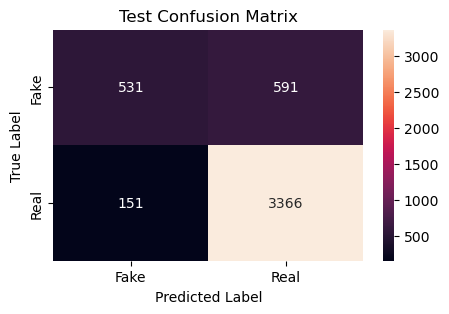

In [128]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [129]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = AdaBoostClassifier()

param_grid = {'n_estimators':[50,100,200], 'learning_rate':[0.01, 0.1, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = AdaBoostClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('AdaB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

AdaB Classifier
Best hyperparameters: {'learning_rate': 1.0, 'n_estimators': 100}
Accuracy:  0.8178486742832507
Precision:  0.8334997503744384
Recall:  0.9493886835371055
F1-score:  0.8876777881164429


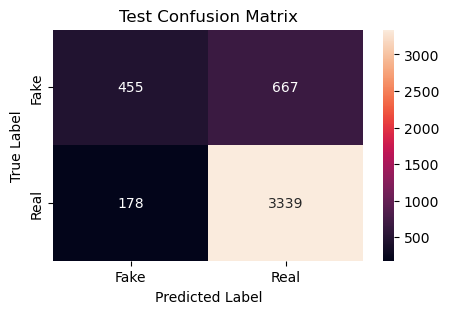

In [130]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [131]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = KNeighborsClassifier()

param_grid = {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance'], 'p':[1,2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = KNeighborsClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('KNN Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

KNN Classifier
Best hyperparameters: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Accuracy:  0.8087949989221815
Precision:  0.8180938558297048
Recall:  0.9616150127949957
F1-score:  0.884067442164423


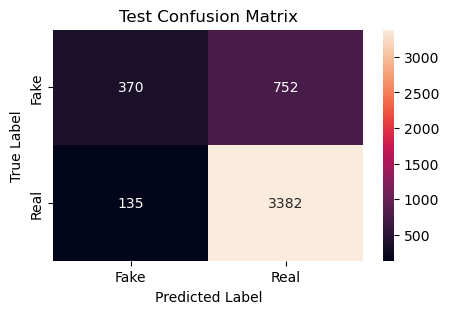

In [132]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [133]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = XGBClassifier()

param_grid = {'learning_rate':[0.01,0.1,0.2], 'n_estimators':[50,100,200], 'max_depth':[3,5,7], 'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0], 'gamma':[0,0.1,0.2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = XGBClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('XGB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

XGB Classifier
Best hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0.2, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy:  0.8333692606165122
Precision:  0.8476938672072986
Recall:  0.951094682968439
F1-score:  0.896422350261289


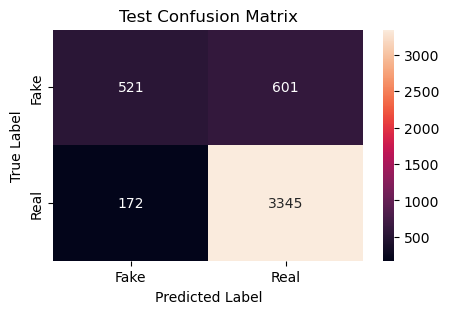

In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [135]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = SVC()

param_grid = {'C':[0.1,1,10,100], 'kernel':['linear','rbf','poly','sigmoid']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = SVC(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('SVM Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

SVM Classifier
Best hyperparameters: {'C': 1, 'kernel': 'rbf'}
Accuracy:  0.8422073722785083
Precision:  0.851552638222671
Recall:  0.9590560136479954
F1-score:  0.9021128644022465


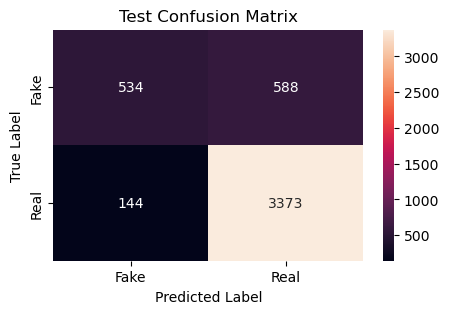

In [136]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [138]:
# DataFrame to csv

train_df.to_csv('train.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)